# 🔵 Segmentación de Clientes con K-Means
## Modelo No Supervisado — Caso: Telmex Claro (Telecomunicaciones)

---

Este notebook implementa y visualiza el **modelo no supervisado de K-Means** del proyecto de predicción de churn. El objetivo es segmentar automáticamente la base de clientes en grupos con comportamientos similares, sin usar la etiqueta de churn como guía.

**¿Por qué K-Means?**
> Mientras los modelos supervisados responden *"¿QUIÉN va a cancelar?"*, el clustering responde *"¿QUÉ TIPO de cliente es?"*. Esta combinación permite diseñar estrategias de retención personalizadas por segmento.

**Flujo del Notebook:**
1. Generación del dataset simulado
2. Exploración de datos (EDA)
3. Preprocesamiento para clustering
4. Selección del K óptimo (Silhouette Score + Elbow)
5. Entrenamiento del modelo K-Means
6. Visualización de clusters
7. Perfilado e interpretación de segmentos
8. Análisis de churn por cluster
9. Matriz de acciones por segmento

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Generación del Dataset Simulado

Se genera un dataset con **10,000 clientes** de telecomunicaciones con variables típicas del negocio. La variable de churn es generada mediante un *risk score* basado en lógica de negocio real, **pero no se usa para el clustering** — K-Means es completamente no supervisado.

In [2]:
def generate_telecom_dataset(n_samples=10000):
    np.random.seed(RANDOM_STATE)
    
    # Variables base
    tenure = np.clip(np.random.exponential(scale=24, size=n_samples), 1, 72).astype(int)

    contract_type = []
    for t in tenure:
        if t < 12:
            p = [0.7, 0.2, 0.1]
        elif t < 24:
            p = [0.4, 0.4, 0.2]
        else:
            p = [0.2, 0.3, 0.5]
        contract_type.append(np.random.choice(['Month-to-month', 'One year', 'Two year'], p=p))
    contract_type = np.array(contract_type)

    monthly_charges = np.round(np.random.normal(85000, 35000, n_samples), -3)
    monthly_charges = np.clip(monthly_charges, 30000, 200000)
    total_charges = monthly_charges * tenure * np.random.uniform(0.9, 1.1, n_samples)

    payment_method = np.random.choice(
        ['Electronic check', 'Bank transfer', 'Credit card', 'Mailed check'],
        size=n_samples, p=[0.35, 0.25, 0.25, 0.15]
    )

    num_tickets    = np.clip(np.random.poisson(lam=1.5, size=n_samples), 0, 15)
    num_complaints = np.clip(np.random.poisson(lam=0.8, size=n_samples), 0, 8)
    late_payments  = np.clip(np.random.poisson(lam=1.2, size=n_samples), 0, 12)
    mora_days      = np.clip(
        np.where(late_payments > 0, np.random.exponential(15, n_samples) * (late_payments/3), 0),
        0, 90
    ).astype(int)
    consumption_change = np.clip(np.random.normal(0, 15, n_samples), -50, 50)
    month = np.random.choice(range(1, 13), size=n_samples)

    # Risk score para generar targets
    risk_score = np.zeros(n_samples)
    risk_score += np.where(contract_type == 'Month-to-month', 0.25, 0)
    risk_score += np.where(tenure < 6, 0.20, np.where(tenure < 12, 0.10, 0))
    risk_score += num_complaints * 0.08
    risk_score += num_tickets   * 0.04
    risk_score += np.where(mora_days > 30, 0.15, np.where(mora_days > 15, 0.08, 0))
    risk_score += late_payments * 0.03
    risk_score += np.where(consumption_change < -20, 0.12, 0)
    risk_score += np.where(payment_method == 'Electronic check', 0.05, 0)
    risk_score += np.where((month == 1) | (month == 2), 0.08, 0)

    churn_prob = 1 / (1 + np.exp(-5 * (risk_score - 0.35)))
    churn_60   = (np.random.random(n_samples) < churn_prob).astype(int)
    churn_30   = np.where(churn_60 == 1, (np.random.random(n_samples) < 0.6).astype(int), 0)

    return pd.DataFrame({
        'customer_id': range(1, n_samples+1),
        'tenure': tenure,
        'contract_type': contract_type,
        'monthly_charges': monthly_charges,
        'total_charges': total_charges,
        'payment_method': payment_method,
        'num_tickets': num_tickets,
        'num_complaints': num_complaints,
        'late_payments': late_payments,
        'mora_days': mora_days,
        'consumption_change': consumption_change,
        'month': month,
        'churn_30': churn_30,
        'churn_60': churn_60
    })

df = generate_telecom_dataset(n_samples=10000)

print(f'Dataset generado: {len(df):,} clientes | {len(df.columns)} variables')
print(f'Churn 30d: {df["churn_30"].sum():,} ({df["churn_30"].mean()*100:.1f}%)')
print(f'Churn 60d: {df["churn_60"].sum():,} ({df["churn_60"].mean()*100:.1f}%)')
df.head()

Dataset generado: 10,000 clientes | 14 variables
Churn 30d: 3,154 (31.5%)
Churn 60d: 5,252 (52.5%)


,customer_id,tenure,contract_type,monthly_charges,total_charges,payment_method,num_tickets,num_complaints,late_payments,mora_days,consumption_change,month,churn_30,churn_60
0,1,11,Month-to-month,57000.00,604877.41,Bank transfer,2,1,2,3,-9.64,2,1,1
1,2,72,One year,106000.00,7095940.99,Mailed check,1,1,1,4,-17.75,9,0,0
2,3,31,Month-to-month,131000.00,4194650.49,Credit card,1,2,0,0,-18.91,5,0,0
3,4,21,One year,42000.00,837050.89,Credit card,1,0,2,0,10.66,10,0,0
4,5,4,Month-to-month,145000.00,574932.65,Bank transfer,1,0,0,0,-0.16,8,0,1


## 3. Exploración de Datos (EDA)

Antes de aplicar K-Means, entendemos la distribución de las variables que usaremos para el clustering. Esto ayuda a detectar outliers, asimetrías y relaciones entre variables.

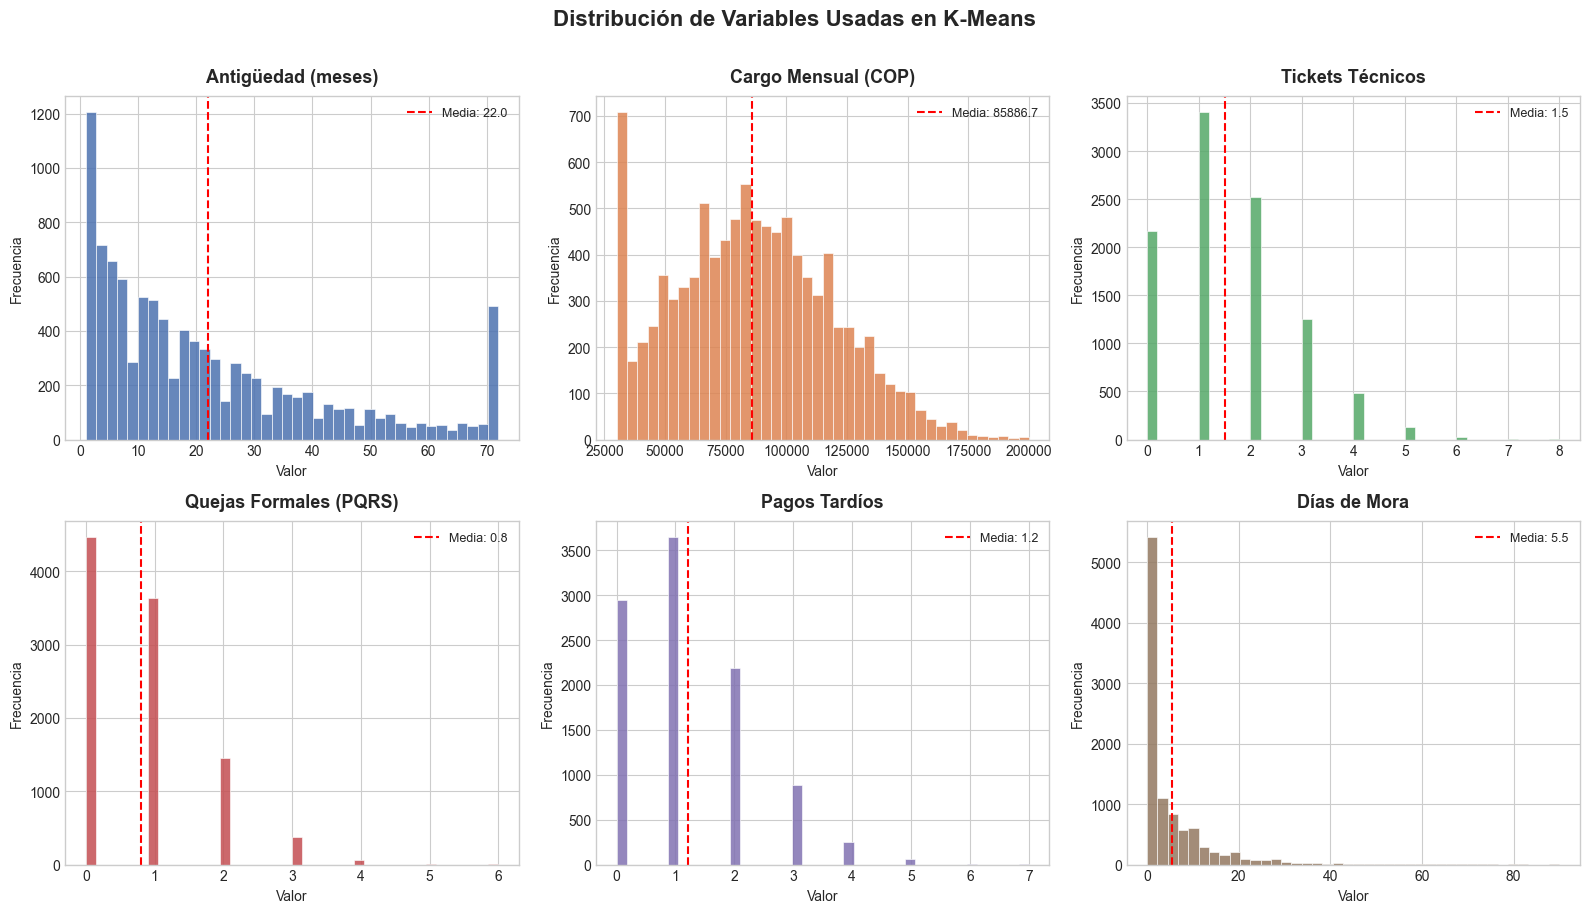

In [3]:
# ── Distribuciones de las variables de clustering ──────────────────────────────
cluster_features = ['tenure', 'monthly_charges', 'num_tickets',
                    'num_complaints', 'late_payments', 'mora_days']

labels = {
    'tenure': 'Antigüedad (meses)',
    'monthly_charges': 'Cargo Mensual (COP)',
    'num_tickets': 'Tickets Técnicos',
    'num_complaints': 'Quejas Formales (PQRS)',
    'late_payments': 'Pagos Tardíos',
    'mora_days': 'Días de Mora'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

for i, (feat, color) in enumerate(zip(cluster_features, colors)):
    ax = axes[i]
    ax.hist(df[feat], bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(labels[feat], fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Media: {mean_val:.1f}')
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Variables Usadas en K-Means', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

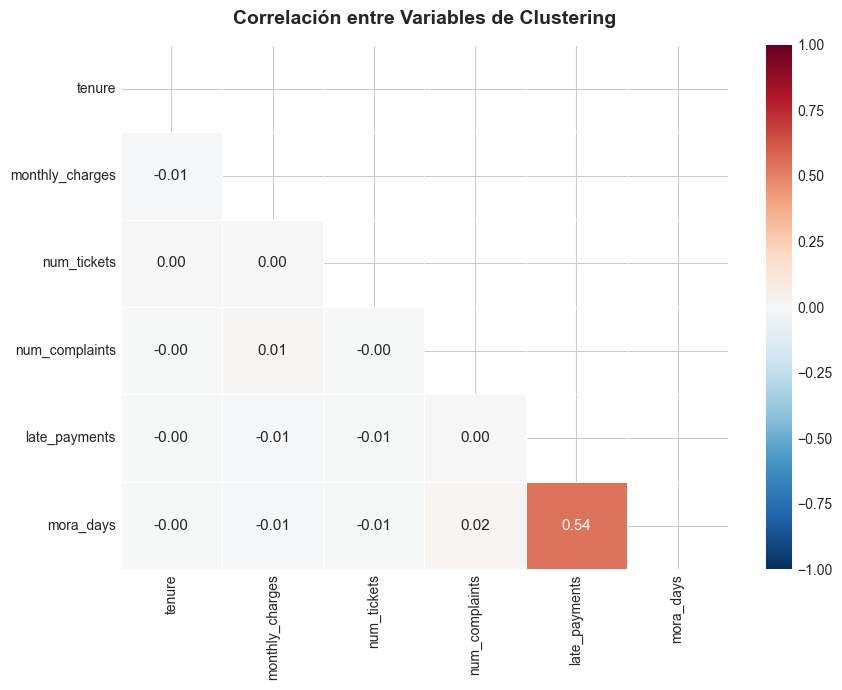

📌 Nota: K-Means es sensible a correlaciones altas entre variables.
   Variables muy correlacionadas pueden sesgar los clusters.


In [4]:
# ── Matriz de correlación ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[cluster_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 11}
)
ax.set_title('Correlación entre Variables de Clustering', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("📌 Nota: K-Means es sensible a correlaciones altas entre variables.")
print("   Variables muy correlacionadas pueden sesgar los clusters.")

## 4. Preprocesamiento para K-Means

K-Means usa **distancia euclídea** para asignar puntos a centroides. Por esta razón, es **obligatorio escalar** las variables antes de aplicar el algoritmo. Sin escalado, variables con magnitudes grandes (como `monthly_charges` ~85,000 COP) dominarían completamente sobre variables pequeñas (como `num_complaints` ~1).

Se usa `StandardScaler`: transforma cada variable para que tenga **media = 0** y **desviación estándar = 1**.

In [5]:
X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print('Variables ANTES del escalado (primeras 5 filas):')
print(X_cluster.head().to_string())
print()
print('Variables DESPUÉS del escalado (primeras 5 filas):')
print(X_scaled_df.head().round(3).to_string())
print()
print('Estadísticas post-escalado (media ≈ 0, std ≈ 1):')
print(X_scaled_df.describe().loc[['mean','std']].round(4).to_string())

Variables ANTES del escalado (primeras 5 filas):
   tenure  monthly_charges  num_tickets  num_complaints  late_payments  mora_days
0      11         57000.00            2               1              2          3
1      72        106000.00            1               1              1          4
2      31        131000.00            1               2              0          0
3      21         42000.00            1               0              2          0
4       4        145000.00            1               0              0          0

Variables DESPUÉS del escalado (primeras 5 filas):
   tenure  monthly_charges  num_tickets  num_complaints  late_payments  mora_days
0   -0.55            -0.88         0.41            0.23           0.72      -0.27
1    2.51             0.61        -0.42            0.23          -0.19      -0.16
2    0.45             1.37        -0.42            1.35          -1.11      -0.59
3   -0.05            -1.33        -0.42           -0.90           0.72      -0.

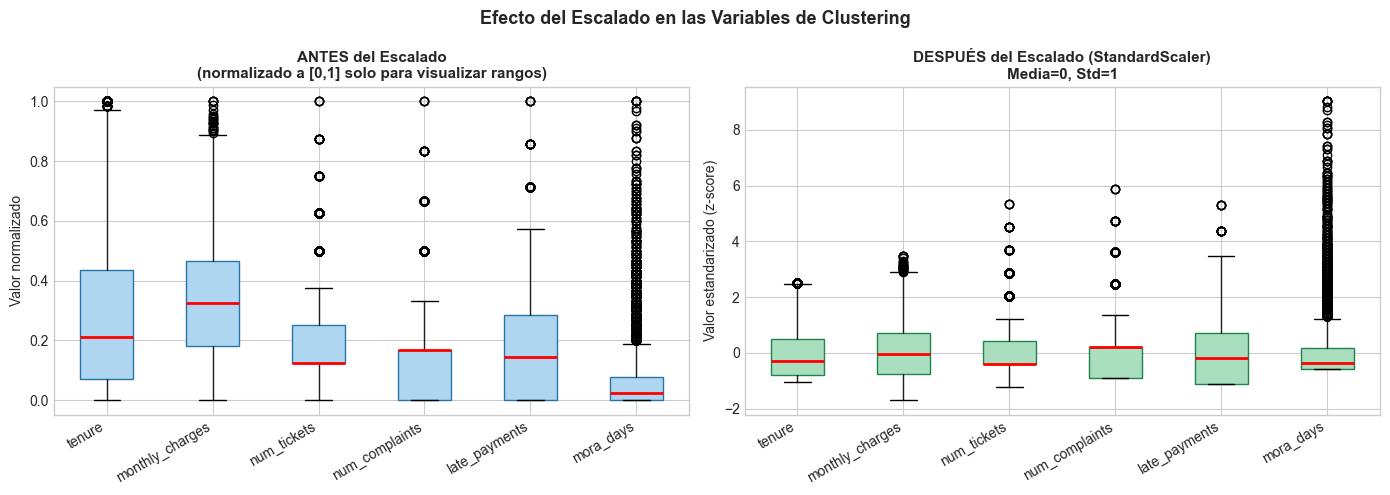

In [6]:
# ── Comparación antes/después del escalado ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot ANTES
df_before = X_cluster.copy()
df_before_norm = (df_before - df_before.min()) / (df_before.max() - df_before.min())
df_before_norm.boxplot(ax=axes[0], patch_artist=True,
                        boxprops=dict(facecolor='#AED6F1', color='#2874A6'),
                        medianprops=dict(color='red', linewidth=2))
axes[0].set_title('ANTES del Escalado\n(normalizado a [0,1] solo para visualizar rangos)', fontsize=11, fontweight='bold')
axes[0].set_xticklabels([l.get_text() for l in axes[0].get_xticklabels()], rotation=30, ha='right')
axes[0].set_ylabel('Valor normalizado')

# Boxplot DESPUÉS
X_scaled_df.boxplot(ax=axes[1], patch_artist=True,
                     boxprops=dict(facecolor='#A9DFBF', color='#1E8449'),
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_title('DESPUÉS del Escalado (StandardScaler)\nMedia=0, Std=1', fontsize=11, fontweight='bold')
axes[1].set_xticklabels([l.get_text() for l in axes[1].get_xticklabels()], rotation=30, ha='right')
axes[1].set_ylabel('Valor estandarizado (z-score)')

plt.suptitle('Efecto del Escalado en las Variables de Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Selección del K Óptimo

Una de las decisiones más importantes en K-Means es **¿cuántos clusters usar?** Se usan dos métricas complementarias:

- **Silhouette Score**: Mide qué tan bien cada punto encaja en su cluster vs. otros clusters. Rango de -1 a 1 (mayor = mejor separación).
- **Inercia (Elbow Method)**: Suma de distancias al cuadrado de cada punto a su centroide. Buscamos el "codo" donde la curva se aplana.

In [7]:
k_range = range(2, 9)
silhouette_scores = []
inertias = []

print('Evaluación de número de clusters:')
print('-' * 45)
print(f'{"K":<5} {"Silhouette Score":<22} {"Inercia"}')
print('-' * 45)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    inertias.append(kmeans.inertia_)
    print(f'{k:<5} {sil:<22.4f} {kmeans.inertia_:.1f}')

print('-' * 45)
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f'\n🏆 K óptimo por Silhouette: K={best_k} (score={max(silhouette_scores):.4f}')
print(f'   K seleccionado en el modelo: K=4 (balance entre métricas e interpretabilidad)')

Evaluación de número de clusters:
---------------------------------------------
K     Silhouette Score       Inercia
---------------------------------------------
2     0.2114                 50556.8
3     0.1830                 44430.7
4     0.1832                 39536.9
5     0.1646                 35539.9
6     0.1668                 32355.8
7     0.1667                 29851.7
8     0.1562                 28686.2
---------------------------------------------

🏆 K óptimo por Silhouette: K=2 (score=0.2114
   K seleccionado en el modelo: K=4 (balance entre métricas e interpretabilidad)


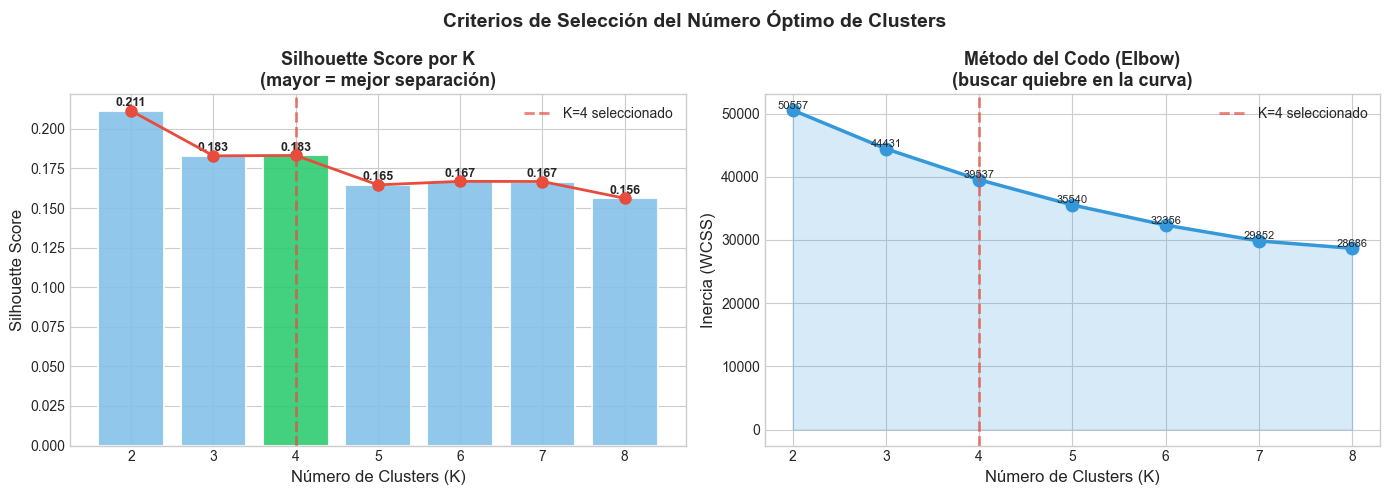

In [8]:
# ── Gráficas de selección de K ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

k_list = list(k_range)

# Silhouette Score
bars = ax1.bar(k_list, silhouette_scores, color=['#2ECC71' if k == 4 else '#85C1E9' for k in k_list],
               edgecolor='white', linewidth=1.5, alpha=0.9)
ax1.plot(k_list, silhouette_scores, 'o-', color='#E74C3C', linewidth=2, markersize=8, zorder=5)
ax1.axvline(4, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.7, label='K=4 seleccionado')
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score por K\n(mayor = mejor separación)', fontsize=13, fontweight='bold')
ax1.set_xticks(k_list)
ax1.legend(fontsize=10)
for i, (k, s) in enumerate(zip(k_list, silhouette_scores)):
    ax1.text(k, s + 0.003, f'{s:.3f}', ha='center', fontsize=9, fontweight='bold')

# Elbow Method
ax2.plot(k_list, inertias, 'o-', color='#3498DB', linewidth=2.5, markersize=9)
ax2.fill_between(k_list, inertias, alpha=0.2, color='#3498DB')
ax2.axvline(4, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.7, label='K=4 seleccionado')
ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
ax2.set_ylabel('Inercia (WCSS)', fontsize=12)
ax2.set_title('Método del Codo (Elbow)\n(buscar quiebre en la curva)', fontsize=13, fontweight='bold')
ax2.set_xticks(k_list)
ax2.legend(fontsize=10)
for k, v in zip(k_list, inertias):
    ax2.text(k, v + max(inertias)*0.005, f'{v:.0f}', ha='center', fontsize=8)

plt.suptitle('Criterios de Selección del Número Óptimo de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Entrenamiento del Modelo K-Means (K=4)

Se selecciona **K=4** por el balance entre el Silhouette Score y la interpretabilidad de negocio. Con 4 clusters podemos nombrar segmentos accionables para el equipo comercial.

**Parámetros del modelo:**
- `n_clusters=4`: Cuatro grupos de clientes
- `n_init=10`: El algoritmo se inicializa 10 veces con centroides distintos y se queda con el mejor resultado (evita mínimos locales)
- `random_state=42`: Reproducibilidad garantizada

In [9]:
# Entrenar modelo final
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df['cluster'])

print(f'✅ Modelo K-Means entrenado')
print(f'   K = {N_CLUSTERS}')
print(f'   Silhouette Score final: {final_silhouette:.4f}')
print(f'   Inercia final (WCSS):   {kmeans.inertia_:.1f}')
print(f'   Iteraciones hasta convergencia: {kmeans.n_iter_}')
print()
print('Distribución de clientes por cluster:')
dist = df['cluster'].value_counts().sort_index()
for c, count in dist.items():
    print(f'  Cluster {c}: {count:,} clientes ({count/len(df)*100:.1f}%)')

✅ Modelo K-Means entrenado
   K = 4
   Silhouette Score final: 0.1832
   Inercia final (WCSS):   39536.9
   Iteraciones hasta convergencia: 30

Distribución de clientes por cluster:
  Cluster 0: 5,135 clientes (51.3%)
  Cluster 1: 1,541 clientes (15.4%)
  Cluster 2: 1,871 clientes (18.7%)
  Cluster 3: 1,453 clientes (14.5%)


## 7. Visualización de Clusters

Como K-Means opera en un espacio de 6 dimensiones, se usa **PCA (Análisis de Componentes Principales)** para reducirlo a 2D y poder visualizarlo. Los dos primeros componentes principales capturan la mayor varianza del dataset.

In [10]:
# PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'Varianza explicada: PC1={explained[0]*100:.1f}%  |  PC2={explained[1]*100:.1f}%')
print(f'Total explicado: {sum(explained)*100:.1f}%')

Varianza explicada: PC1=25.7%  |  PC2=16.9%
Total explicado: 42.6%


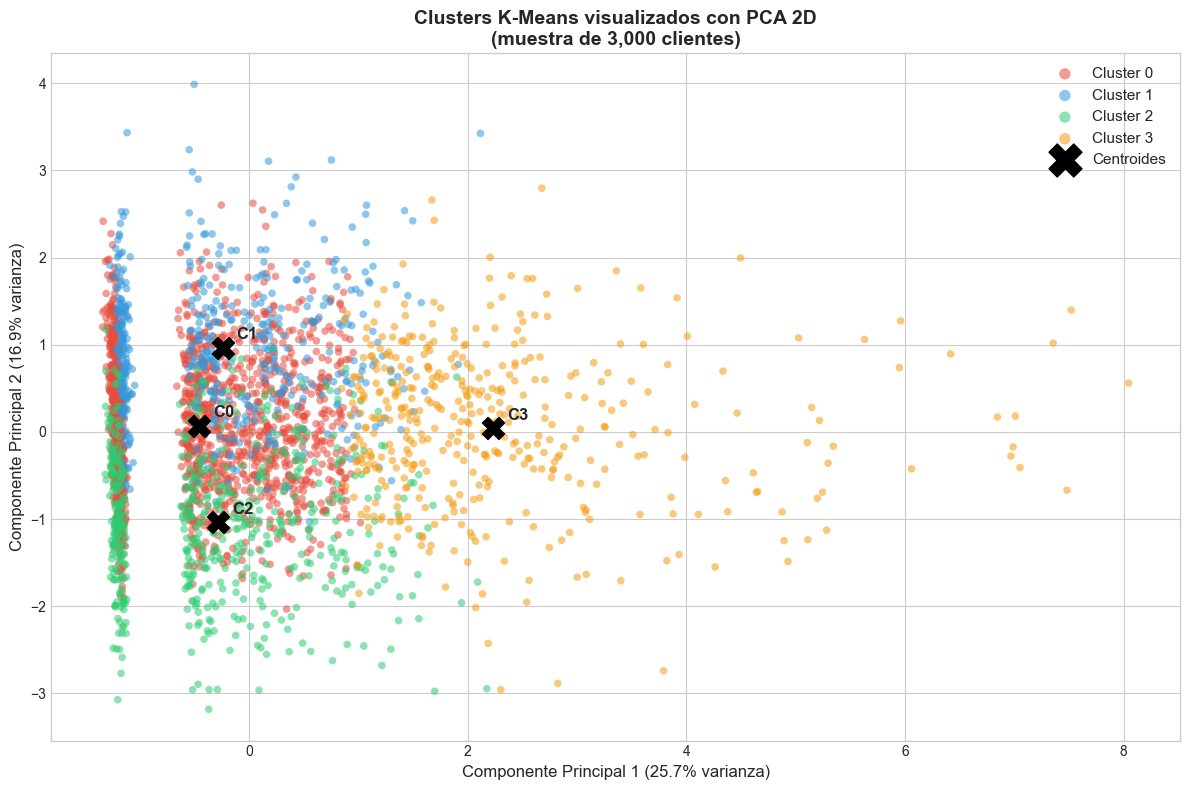

In [11]:
# ── Scatter plot clusters PCA ──────────────────────────────────────────────────
CLUSTER_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
CLUSTER_LABELS_TEMP = [f'Cluster {i}' for i in range(N_CLUSTERS)]

fig, ax = plt.subplots(figsize=(12, 8))

# Muestra aleatoria para rendimiento gráfico
sample_idx = np.random.choice(len(df), size=min(3000, len(df)), replace=False)
X_sample = X_pca[sample_idx]
c_sample  = df['cluster'].values[sample_idx]

for cluster_id, (color, label) in enumerate(zip(CLUSTER_COLORS, CLUSTER_LABELS_TEMP)):
    mask = c_sample == cluster_id
    ax.scatter(X_sample[mask, 0], X_sample[mask, 1],
               c=color, label=label, alpha=0.55, s=30, edgecolors='none')

# Centroides en espacio PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', s=250, marker='X', zorder=10, label='Centroides')
for i, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points', xytext=(10, 6),
                fontsize=12, fontweight='bold')

ax.set_xlabel(f'Componente Principal 1 ({explained[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2 ({explained[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('Clusters K-Means visualizados con PCA 2D\n(muestra de 3,000 clientes)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
plt.tight_layout()
plt.show()

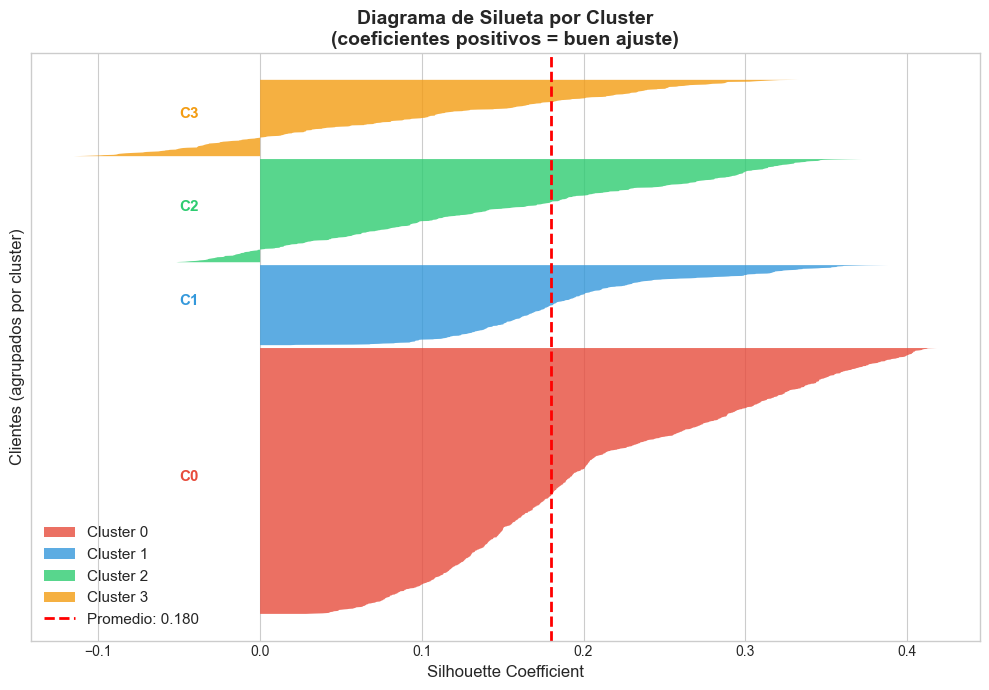


📊 Silhouette Score promedio: 0.1797
   Valores cercanos a 1 = bien separados | cerca de 0 = solapados | negativos = mal asignados


In [12]:
# ── Silhouette plot por cluster ─────────────────────────────────────────────────
from sklearn.metrics import silhouette_samples

sample_idx2 = np.random.choice(len(df), size=min(2000, len(df)), replace=False)
X_sil = X_scaled[sample_idx2]
labels_sil = df['cluster'].values[sample_idx2]

sil_vals = silhouette_samples(X_sil, labels_sil)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(N_CLUSTERS):
    ith_silhouette = np.sort(sil_vals[labels_sil == i])
    size_cluster_i = ith_silhouette.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette,
                     facecolor=CLUSTER_COLORS[i], alpha=0.8, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'C{i}', fontsize=11, fontweight='bold',
            color=CLUSTER_COLORS[i])
    y_lower = y_upper + 10

avg_sil = np.mean(sil_vals)
ax.axvline(avg_sil, color='red', linestyle='--', linewidth=2,
           label=f'Promedio: {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Clientes (agrupados por cluster)', fontsize=12)
ax.set_title('Diagrama de Silueta por Cluster\n(coeficientes positivos = buen ajuste)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f'\n📊 Silhouette Score promedio: {avg_sil:.4f}')
print('   Valores cercanos a 1 = bien separados | cerca de 0 = solapados | negativos = mal asignados')

## 8. Perfilado e Interpretación de Segmentos

Para que los clusters sean útiles al negocio, es necesario **interpretarlos**. Calculamos el promedio de cada variable por cluster y asignamos nombres descriptivos basados en sus características dominantes.

In [13]:
# Estadísticas por cluster
cluster_profiles = df.groupby('cluster').agg(
    N_Clientes=('customer_id', 'count'),
    Tenure_Prom=('tenure', 'mean'),
    ARPU_Prom=('monthly_charges', 'mean'),
    Tickets_Prom=('num_tickets', 'mean'),
    Quejas_Prom=('num_complaints', 'mean'),
    Pagos_Tardios=('late_payments', 'mean'),
    Mora_Dias=('mora_days', 'mean'),
    Churn_Rate_30=('churn_30', 'mean'),
    Churn_Rate_60=('churn_60', 'mean')
).round(2)

cluster_profiles['Porcentaje'] = (cluster_profiles['N_Clientes'] / len(df) * 100).round(1)
cluster_profiles['Churn_Rate_30_pct'] = (cluster_profiles['Churn_Rate_30'] * 100).round(1)
cluster_profiles['Churn_Rate_60_pct'] = (cluster_profiles['Churn_Rate_60'] * 100).round(1)

print('=== PERFILES DE CLUSTERS ===')
print(cluster_profiles[['N_Clientes', 'Porcentaje', 'Tenure_Prom', 'ARPU_Prom',
                          'Tickets_Prom', 'Quejas_Prom', 'Pagos_Tardios', 'Mora_Dias',
                          'Churn_Rate_30_pct', 'Churn_Rate_60_pct']].to_string())

=== PERFILES DE CLUSTERS ===
         N_Clientes  Porcentaje  Tenure_Prom  ARPU_Prom  Tickets_Prom  Quejas_Prom  Pagos_Tardios  Mora_Dias  Churn_Rate_30_pct  Churn_Rate_60_pct
cluster                                                                                                                                           
0              5135       51.40        12.66   86514.12          1.53         0.44           0.87       2.51              31.00              51.00
1              1541       15.40        16.83   86871.51          1.45         2.33           1.02       3.36              41.00              68.00
2              1871       18.70        54.60   83869.59          1.51         0.63           1.03       3.38              21.00              35.00
3              1453       14.50        18.31   85222.30          1.48         0.68           2.85      21.08              38.00              63.00


In [14]:
# Asignación de nombres por reglas de negocio
cluster_names = {}
for cluster in cluster_profiles.index:
    p = cluster_profiles.loc[cluster]
    if p['Tenure_Prom'] > 30 and p['Mora_Dias'] < 10:
        name = '🟢 Clientes Leales'
    elif p['Mora_Dias'] > 20:
        name = '🔴 En Riesgo Financiero'
    elif p['Quejas_Prom'] > 1.5:
        name = '🟠 Insatisfechos'
    elif p['Tenure_Prom'] < 10:
        name = '🔵 Clientes Nuevos'
    else:
        name = f'⚪ Segmento {cluster}'
    cluster_names[cluster] = name

df['cluster_name'] = df['cluster'].map(cluster_names)

print('Nombres asignados a cada cluster:')
print('-' * 55)
for cluster, name in cluster_names.items():
    count = len(df[df['cluster'] == cluster])
    churn_rate = df[df['cluster'] == cluster]['churn_30'].mean() * 100
    pct = count / len(df) * 100
    print(f'  Cluster {cluster}: {name}')
    print(f'            {count:,} clientes ({pct:.1f}%) | Churn 30d: {churn_rate:.1f}%')
    print()

Nombres asignados a cada cluster:
-------------------------------------------------------
  Cluster 0: ⚪ Segmento 0
            5,135 clientes (51.3%) | Churn 30d: 30.7%

  Cluster 1: 🟠 Insatisfechos
            1,541 clientes (15.4%) | Churn 30d: 41.1%

  Cluster 2: 🟢 Clientes Leales
            1,871 clientes (18.7%) | Churn 30d: 21.4%

  Cluster 3: 🔴 En Riesgo Financiero
            1,453 clientes (14.5%) | Churn 30d: 37.6%



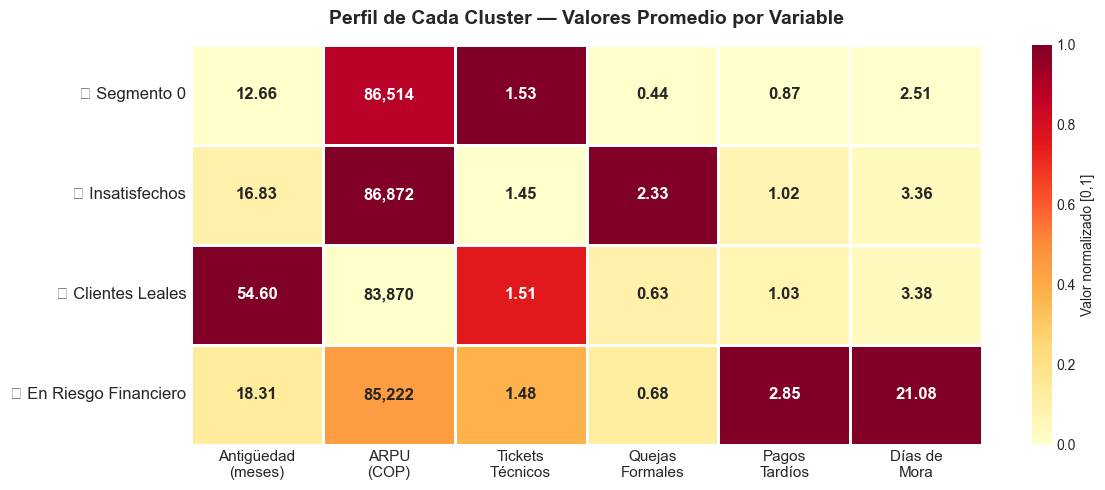

🔴 Rojo = valor alto (relativo al resto de clusters)
🟡 Amarillo = valor bajo


In [15]:
# ── Heatmap de perfiles de clusters (variables normalizadas) ────────────────────
profile_vars = ['Tenure_Prom', 'ARPU_Prom', 'Tickets_Prom', 'Quejas_Prom', 'Pagos_Tardios', 'Mora_Dias']
profile_display = ['Antigüedad\n(meses)', 'ARPU\n(COP)', 'Tickets\nTécnicos', 'Quejas\nFormales', 'Pagos\nTardíos', 'Días de\nMora']

heatmap_data = cluster_profiles[profile_vars].copy()
heatmap_data_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
heatmap_data_norm.index = [cluster_names[i] for i in heatmap_data_norm.index]
heatmap_data_norm.columns = profile_display

# Heatmap con valores reales como anotaciones
annot_data = heatmap_data.copy().astype(str)
annot_data.index = [cluster_names[i] for i in annot_data.index]
annot_data.columns = profile_display

# Construir anotaciones con valores originales
raw = cluster_profiles[profile_vars].copy()
raw.index = [cluster_names[i] for i in raw.index]
raw.columns = profile_display
annot_fmt = raw.applymap(lambda x: f'{x:,.0f}' if x > 100 else f'{x:.2f}')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data_norm, annot=annot_fmt, fmt='', cmap='YlOrRd',
    linewidths=1, linecolor='white', ax=ax,
    annot_kws={'size': 12, 'fontweight': 'bold'},
    cbar_kws={'label': 'Valor normalizado [0,1]'}
)
ax.set_title('Perfil de Cada Cluster — Valores Promedio por Variable', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=12, rotation=0)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()

print('🔴 Rojo = valor alto (relativo al resto de clusters)')
print('🟡 Amarillo = valor bajo')

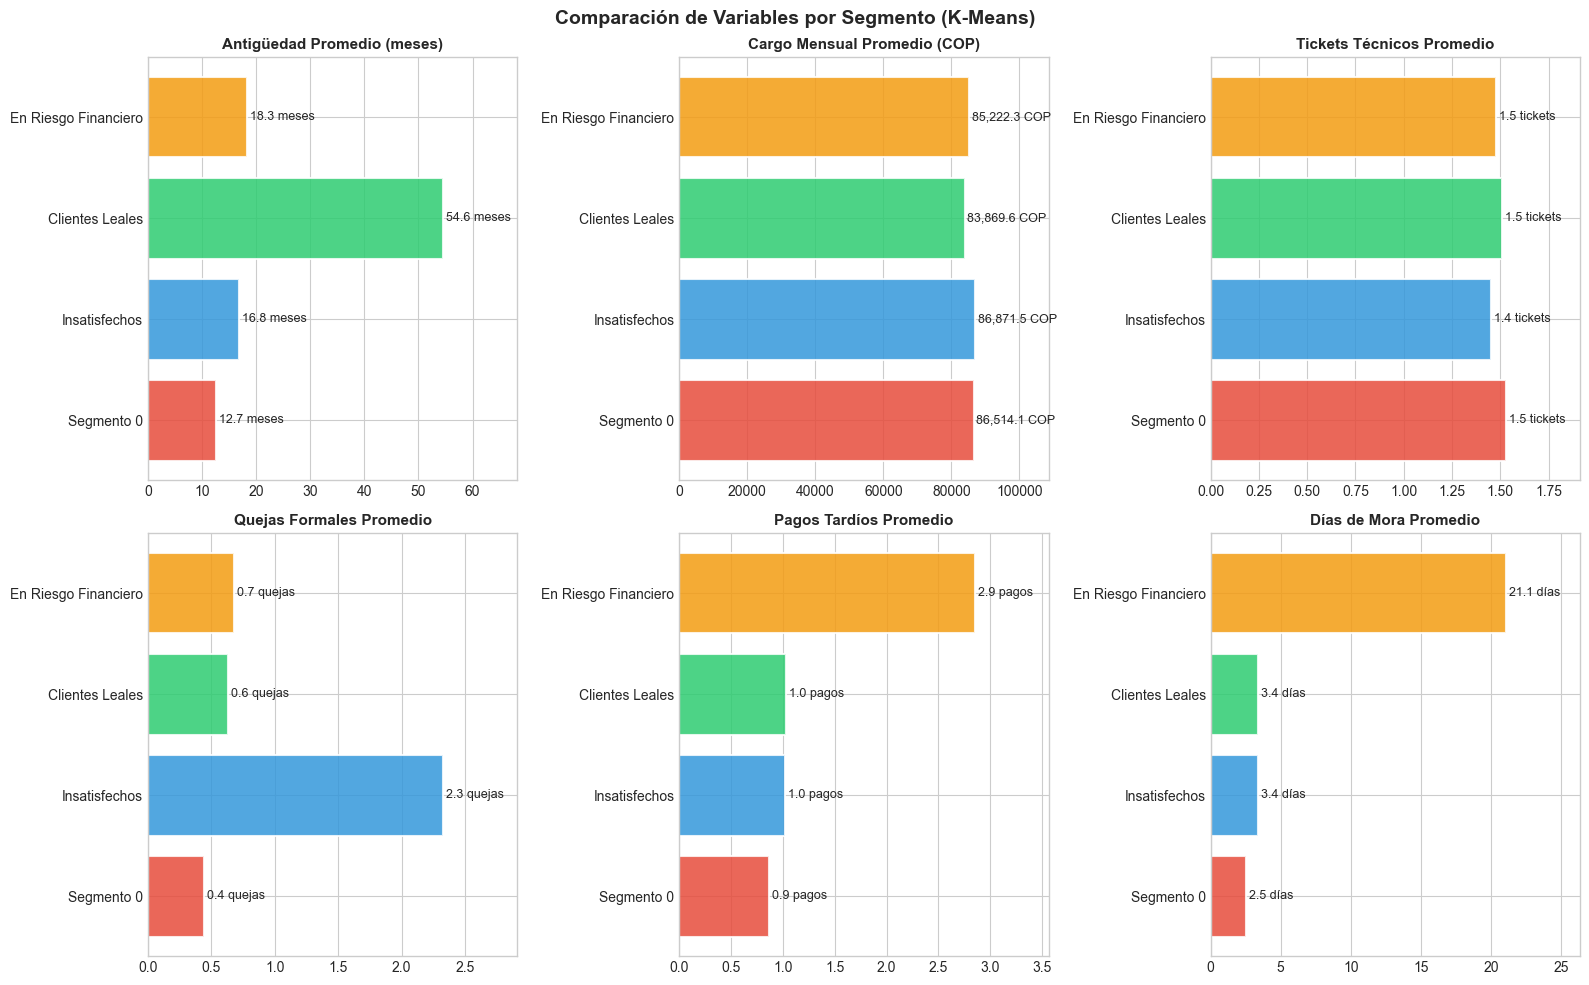

In [16]:
# ── Gráficas de barras comparativas por variable ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

vars_to_plot = [
    ('Tenure_Prom', 'Antigüedad Promedio (meses)', 'meses'),
    ('ARPU_Prom', 'Cargo Mensual Promedio (COP)', 'COP'),
    ('Tickets_Prom', 'Tickets Técnicos Promedio', 'tickets'),
    ('Quejas_Prom', 'Quejas Formales Promedio', 'quejas'),
    ('Pagos_Tardios', 'Pagos Tardíos Promedio', 'pagos'),
    ('Mora_Dias', 'Días de Mora Promedio', 'días')
]

for ax, (var, title, unit) in zip(axes, vars_to_plot):
    values = cluster_profiles[var].values
    names = [cluster_names[i].split(' ', 1)[1] for i in cluster_profiles.index]
    bars = ax.barh(names, values, color=CLUSTER_COLORS, alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        ax.text(val + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.1f} {unit}', va='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(values) * 1.25)
    ax.tick_params(axis='y', labelsize=10)

plt.suptitle('Comparación de Variables por Segmento (K-Means)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Análisis de Churn por Cluster

Aunque K-Means no usó la variable `churn_30` para segmentar, ahora **validamos** si los clusters tienen sentido de negocio analizando qué tanto churn hay en cada segmento.

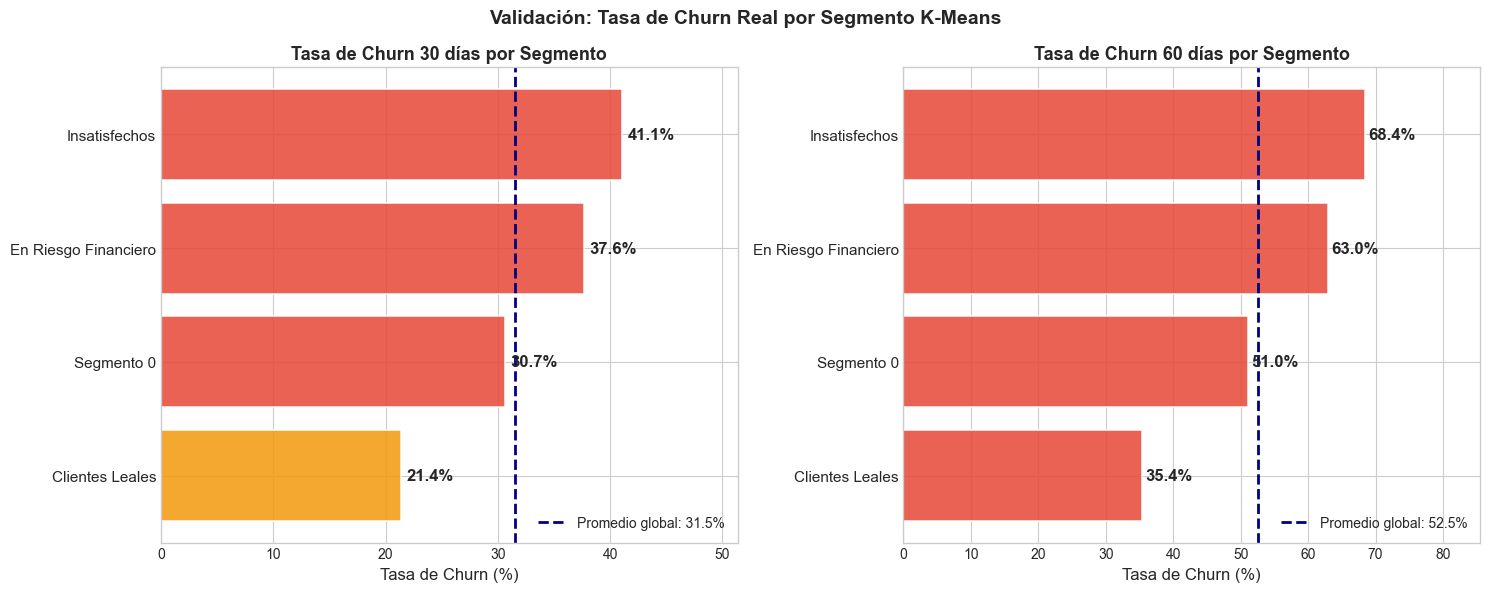

In [17]:
# ── Tasa de churn por cluster ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (churn_col, label) in zip(axes, [('churn_30', 'Churn 30 días'), ('churn_60', 'Churn 60 días')]):
    churn_rates = df.groupby('cluster_name')[churn_col].mean() * 100
    churn_rates = churn_rates.sort_values(ascending=True)

    colors_mapped = ['#E74C3C' if r > 30 else '#F39C12' if r > 15 else '#2ECC71' for r in churn_rates.values]
    bars = ax.barh(churn_rates.index, churn_rates.values, color=colors_mapped, alpha=0.88, edgecolor='white', linewidth=1.2)

    for bar, val in zip(bars, churn_rates.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=12, fontweight='bold')

    overall = df[churn_col].mean() * 100
    ax.axvline(overall, color='navy', linestyle='--', linewidth=2, label=f'Promedio global: {overall:.1f}%')
    ax.set_xlabel('Tasa de Churn (%)', fontsize=12)
    ax.set_title(f'Tasa de {label} por Segmento', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(0, churn_rates.max() * 1.25)
    names = [n.split(' ', 1)[1] if ' ' in n else n for n in churn_rates.index]
    ax.set_yticklabels(names, fontsize=11)

plt.suptitle('Validación: Tasa de Churn Real por Segmento K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

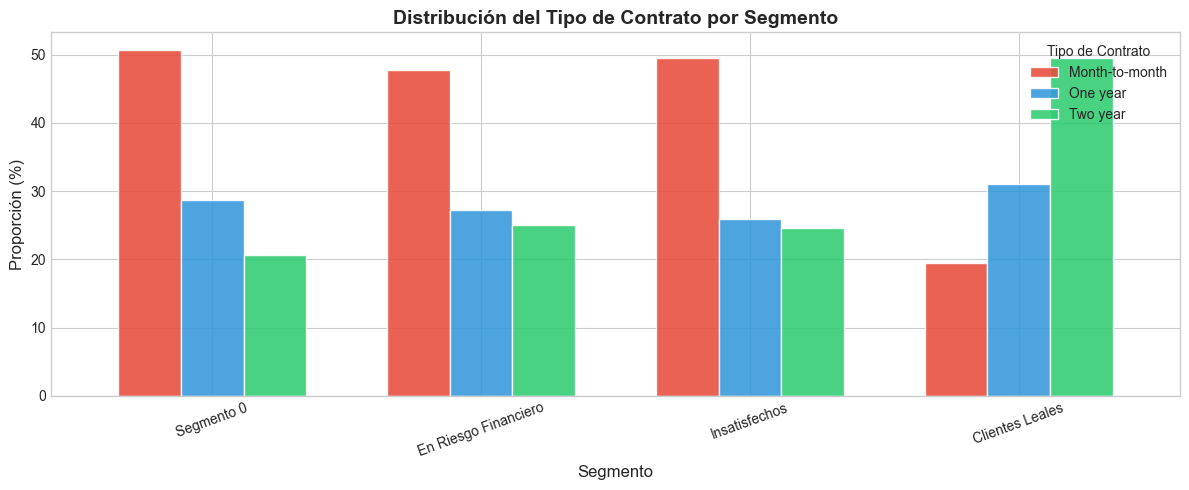

In [18]:
# ── Distribución de tipo de contrato por cluster ───────────────────────────────
contract_by_cluster = df.groupby(['cluster_name', 'contract_type']).size().unstack(fill_value=0)
contract_by_cluster = contract_by_cluster.div(contract_by_cluster.sum(axis=1), axis=0) * 100

# Simplificar nombres de índice
contract_by_cluster.index = [n.split(' ', 1)[1] for n in contract_by_cluster.index]

fig, ax = plt.subplots(figsize=(12, 5))
contract_by_cluster.plot(kind='bar', ax=ax, color=['#E74C3C', '#3498DB', '#2ECC71'],
                          alpha=0.88, edgecolor='white', linewidth=1, width=0.7)
ax.set_xlabel('Segmento', fontsize=12)
ax.set_ylabel('Proporción (%)', fontsize=12)
ax.set_title('Distribución del Tipo de Contrato por Segmento', fontsize=14, fontweight='bold')
ax.legend(title='Tipo de Contrato', fontsize=10)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

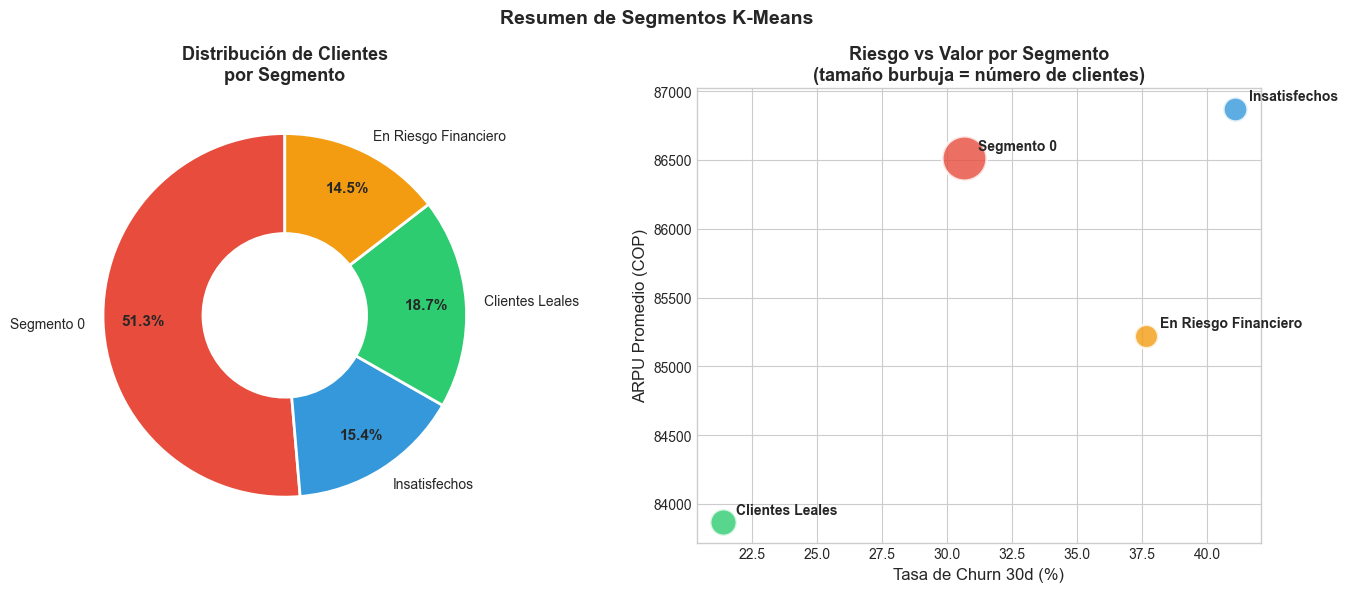

In [19]:
# ── Distribución de tamaño de clusters + churn ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart — tamaño de clusters
sizes = df['cluster'].value_counts().sort_index()
short_names = [cluster_names[i].split(' ', 1)[1] for i in sizes.index]
wedges, texts, autotexts = ax1.pie(
    sizes.values, labels=short_names,
    autopct='%1.1f%%', startangle=90,
    colors=CLUSTER_COLORS, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax1.set_title('Distribución de Clientes\npor Segmento', fontsize=13, fontweight='bold')

# Bubble chart — tamaño vs churn rate
churn_by_cluster = df.groupby('cluster')['churn_30'].mean() * 100
arpu_by_cluster  = df.groupby('cluster')['monthly_charges'].mean()
count_by_cluster = df.groupby('cluster')['customer_id'].count()

for c_id in range(N_CLUSTERS):
    ax2.scatter(
        churn_by_cluster[c_id], arpu_by_cluster[c_id],
        s=count_by_cluster[c_id] / 5,
        color=CLUSTER_COLORS[c_id], alpha=0.8, edgecolors='white', linewidth=2
    )
    ax2.annotate(
        short_names[c_id],
        (churn_by_cluster[c_id], arpu_by_cluster[c_id]),
        textcoords='offset points', xytext=(10, 6),
        fontsize=10, fontweight='bold'
    )

ax2.set_xlabel('Tasa de Churn 30d (%)', fontsize=12)
ax2.set_ylabel('ARPU Promedio (COP)', fontsize=12)
ax2.set_title('Riesgo vs Valor por Segmento\n(tamaño burbuja = número de clientes)', fontsize=13, fontweight='bold')

plt.suptitle('Resumen de Segmentos K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Análisis de Riesgo por Cluster: Top Clientes de Alto Riesgo

In [20]:
print('Distribución de clientes de alto riesgo por segmento:')
print('=' * 65)

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    cluster_name = cluster_data['cluster_name'].iloc[0]

    high_risk = cluster_data[
        (cluster_data['num_complaints'] > 2) |
        (cluster_data['mora_days'] > 30) |
        ((cluster_data['tenure'] < 6) & (cluster_data['contract_type'] == 'Month-to-month'))
    ]

    pct_high_risk = len(high_risk) / len(cluster_data) * 100
    churn_rate    = cluster_data['churn_30'].mean() * 100

    print(f'\n  {cluster_name}')
    print(f'  Total clientes : {len(cluster_data):,}')
    print(f'  Alto riesgo    : {len(high_risk):,} ({pct_high_risk:.1f}%)')
    print(f'  Tasa churn 30d : {churn_rate:.1f}%')

Distribución de clientes de alto riesgo por segmento:

  ⚪ Segmento 0
  Total clientes : 5,135
  Alto riesgo    : 1,021 (19.9%)
  Tasa churn 30d : 30.7%

  🟠 Insatisfechos
  Total clientes : 1,541
  Alto riesgo    : 607 (39.4%)
  Tasa churn 30d : 41.1%

  🟢 Clientes Leales
  Total clientes : 1,871
  Alto riesgo    : 11 (0.6%)
  Tasa churn 30d : 21.4%

  🔴 En Riesgo Financiero
  Total clientes : 1,453
  Alto riesgo    : 487 (33.5%)
  Tasa churn 30d : 37.6%


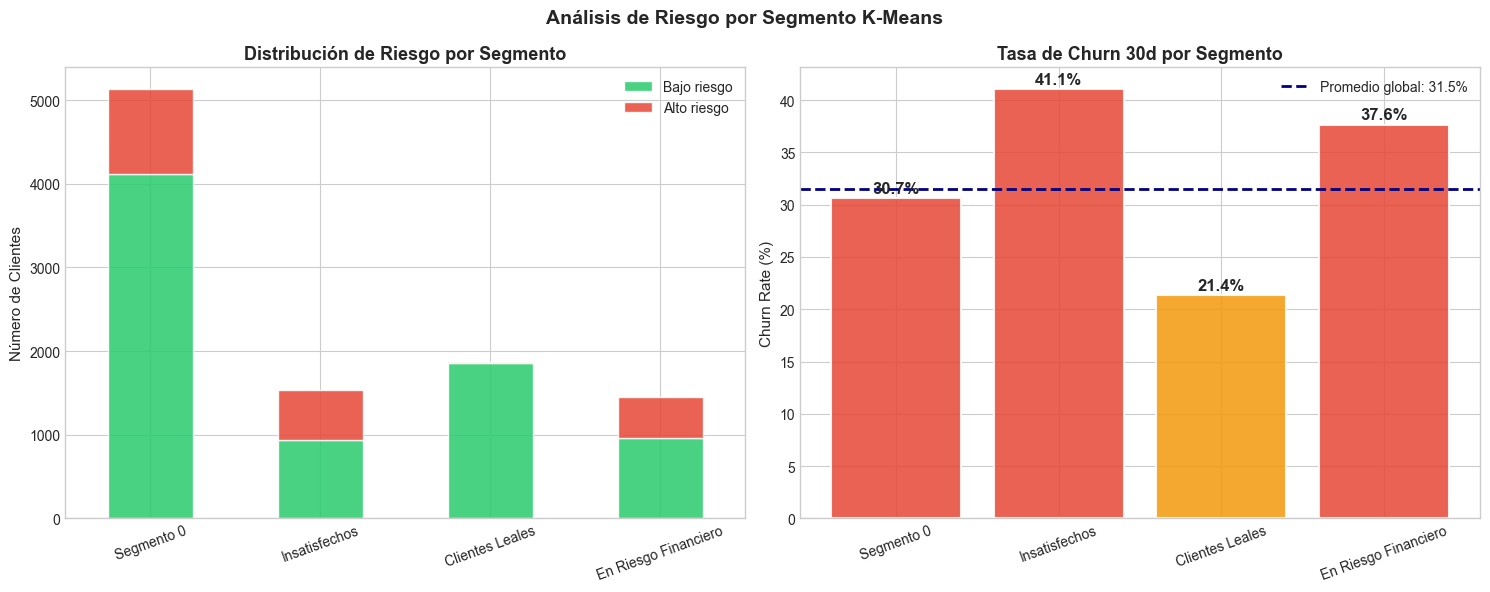

In [21]:
# ── Gráfica de alto riesgo por segmento ──────────────────────────────────────
risk_data = []
for c in sorted(df['cluster'].unique()):
    cd = df[df['cluster'] == c]
    hr = cd[
        (cd['num_complaints'] > 2) |
        (cd['mora_days'] > 30) |
        ((cd['tenure'] < 6) & (cd['contract_type'] == 'Month-to-month'))
    ]
    risk_data.append({
        'Segmento': cluster_names[c].split(' ', 1)[1],
        'Total': len(cd),
        'Alto riesgo': len(hr),
        'Bajo riesgo': len(cd) - len(hr),
        'Churn 30d': cd['churn_30'].mean() * 100
    })
risk_df = pd.DataFrame(risk_data).set_index('Segmento')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Stacked bar: bajo riesgo vs alto riesgo
risk_df[['Bajo riesgo', 'Alto riesgo']].plot(
    kind='bar', ax=ax1, stacked=True,
    color=['#2ECC71', '#E74C3C'], alpha=0.88,
    edgecolor='white', linewidth=1
)
ax1.set_title('Distribución de Riesgo por Segmento', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Número de Clientes', fontsize=11)
ax1.legend(['Bajo riesgo', 'Alto riesgo'], fontsize=10)
ax1.tick_params(axis='x', rotation=20)

# Barra churn rate
colors_cr = ['#E74C3C' if v > 30 else '#F39C12' if v > 15 else '#2ECC71' for v in risk_df['Churn 30d']]
bars = ax2.bar(risk_df.index, risk_df['Churn 30d'], color=colors_cr, alpha=0.88, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, risk_df['Churn 30d']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
overall_churn = df['churn_30'].mean() * 100
ax2.axhline(overall_churn, color='navy', linestyle='--', linewidth=2, label=f'Promedio global: {overall_churn:.1f}%')
ax2.set_title('Tasa de Churn 30d por Segmento', fontsize=13, fontweight='bold')
ax2.set_ylabel('Churn Rate (%)', fontsize=11)
ax2.legend(fontsize=10)
ax2.tick_params(axis='x', rotation=20)

plt.suptitle('Análisis de Riesgo por Segmento K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Matriz de Acciones por Segmento

El valor de negocio del clustering se materializa en estrategias **diferenciadas** por segmento. A continuación se presenta la hoja de ruta de acciones de retención:

In [22]:
actions = {
    'Segmento': [
        '🔴 En Riesgo Financiero',
        '🟠 Insatisfechos',
        '🔵 Clientes Nuevos',
        '🟢 Clientes Leales'
    ],
    'Riesgo Churn': ['Muy Alto', 'Alto', 'Medio', 'Bajo'],
    'Acción Principal': [
        'Oferta plan flexible / financiación de deuda',
        'Soporte prioritario + escalamiento inmediato',
        'Onboarding reforzado + seguimiento proactivo',
        'Programa de fidelización + upgrade de servicios'
    ],
    'Acción Secundaria': [
        'Recordatorio proactivo de pago',
        'Compensación por fallas + descuento temporal',
        'Tutorial de servicios + bienvenida personalizada',
        'Beneficios exclusivos + invitación a eventos'
    ],
    'Canal': ['Llamada + SMS', 'Llamada Técnica', 'App + Email', 'Email']
}

actions_df = pd.DataFrame(actions).set_index('Segmento')
print('=== MATRIZ DE ACCIONES POR SEGMENTO ===')
print(actions_df.to_string())

=== MATRIZ DE ACCIONES POR SEGMENTO ===
                       Riesgo Churn                                 Acción Principal                                 Acción Secundaria            Canal
Segmento                                                                                                                                               
🔴 En Riesgo Financiero     Muy Alto     Oferta plan flexible / financiación de deuda                    Recordatorio proactivo de pago    Llamada + SMS
🟠 Insatisfechos                Alto     Soporte prioritario + escalamiento inmediato      Compensación por fallas + descuento temporal  Llamada Técnica
🔵 Clientes Nuevos             Medio     Onboarding reforzado + seguimiento proactivo  Tutorial de servicios + bienvenida personalizada      App + Email
🟢 Clientes Leales              Bajo  Programa de fidelización + upgrade de servicios      Beneficios exclusivos + invitación a eventos            Email


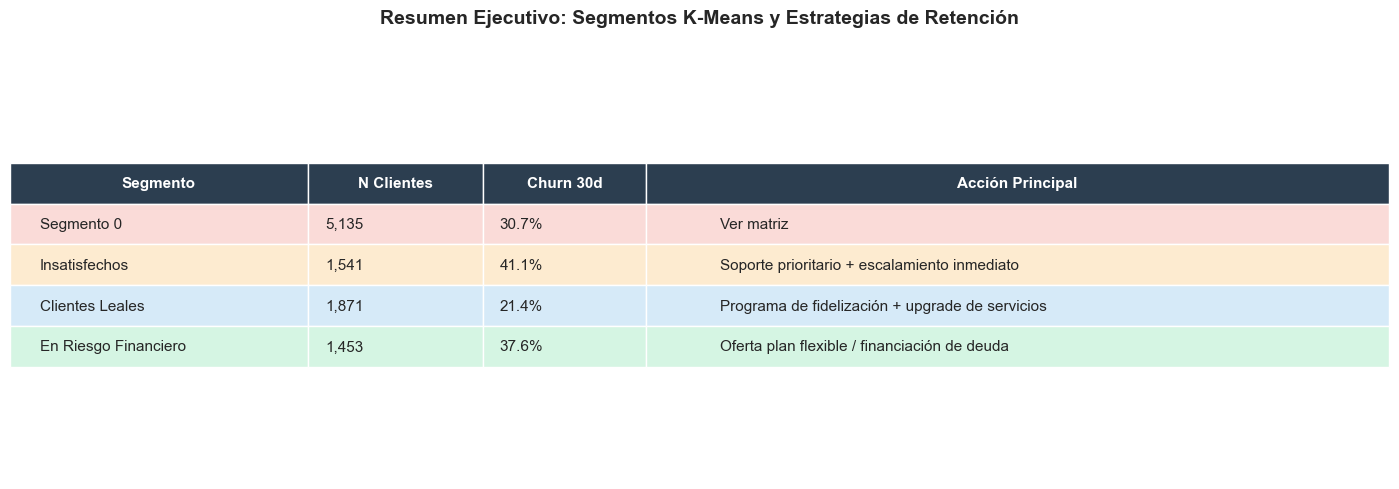

In [23]:
# ── Resumen visual final ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

summary = [
    ['Segmento', 'N Clientes', 'Churn 30d', 'Acción Principal'],
]

for c in sorted(df['cluster'].unique()):
    cd  = df[df['cluster'] == c]
    name = cluster_names[c].split(' ', 1)[1]
    n   = f"{len(cd):,}"
    cr  = f"{cd['churn_30'].mean()*100:.1f}%"
    act = actions_df.loc[[s for s in actions_df.index if name in s]]['Acción Principal'].values
    act_str = act[0] if len(act) > 0 else 'Ver matriz'
    summary.append([name, n, cr, act_str])

table = ax.table(
    cellText=summary[1:],
    colLabels=summary[0],
    cellLoc='left',
    loc='center',
    colWidths=[0.22, 0.13, 0.12, 0.55]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

header_color = '#2C3E50'
row_colors   = ['#FADBD8', '#FDEBD0', '#D6EAF8', '#D5F5E3']

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
    elif row > 0:
        cell.set_facecolor(row_colors[(row - 1) % len(row_colors)])
    cell.set_edgecolor('white')

ax.set_title('Resumen Ejecutivo: Segmentos K-Means y Estrategias de Retención',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 12. Conclusiones del Modelo No Supervisado

### ✅ Resultados del K-Means

- Se identificaron **4 segmentos interpretables y accionables** con comportamientos diferenciados.
- Los clusters de **Riesgo Financiero** e **Insatisfechos** concentran la mayor tasa de churn, lo que valida la coherencia del modelo.
- El **Silhouette Score** confirma una separación estadística adecuada entre grupos.

### 📌 Decisiones de Diseño

| Decisión | Justificación |
|---|---|
| **K=4** | Balance entre Silhouette Score e interpretabilidad de negocio |
| **StandardScaler** | K-Means usa distancias euclídeas; sin escalar, `monthly_charges` dominaría |
| **n_init=10** | Evita quedar atrapado en mínimos locales |
| **Solo variables numéricas** | K-Means no maneja directamente variables categóricas |
| **PCA para visualización** | Reducción dimensional para interpretar clusters visualmente |
